In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/data.csv")
df.head()

,air_store_id,visit_date,day_of_week,holiday_flg,air_genre_name,air_area_name,latitude,longitude,visitors
0,air_ba937bf13d40fb24,2016-01-13,Wednesday,0,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,25
1,air_ba937bf13d40fb24,2016-01-14,Thursday,0,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,32
2,air_ba937bf13d40fb24,2016-01-15,Friday,0,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,29
3,air_ba937bf13d40fb24,2016-01-16,Saturday,0,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,22
4,air_ba937bf13d40fb24,2016-01-18,Monday,0,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252108 entries, 0 to 252107
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   air_store_id    252108 non-null  object 
 1   visit_date      252108 non-null  object 
 2   day_of_week     252108 non-null  object 
 3   holiday_flg     252108 non-null  int64  
 4   air_genre_name  252108 non-null  object 
 5   air_area_name   252108 non-null  object 
 6   latitude        252108 non-null  float64
 7   longitude       252108 non-null  float64
 8   visitors        252108 non-null  int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 17.3+ MB


In [4]:
df.isna().sum()

air_store_id      0
visit_date        0
day_of_week       0
holiday_flg       0
air_genre_name    0
air_area_name     0
latitude          0
longitude         0
visitors          0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df['air_store_id'].nunique()

829

In [7]:
df['visit_date'] = pd.to_datetime(df['visit_date'])
df['visit_date'].min(), df['visit_date'].max()

(Timestamp('2016-01-01 00:00:00'), Timestamp('2017-04-22 00:00:00'))

In [8]:
df['visit_date'].max() - df['visit_date'].min()

Timedelta('477 days 00:00:00')

In [9]:
df.groupby('day_of_week')['visitors'].mean().sort_values(ascending=False)

day_of_week
Saturday     26.313688
Sunday       23.873362
Friday       23.072737
Wednesday    19.230121
Thursday     18.922702
Tuesday      17.672137
Monday       17.177009
Name: visitors, dtype: float64

In [10]:
df.groupby('holiday_flg')['visitors'].mean()

holiday_flg
0    20.828064
1    23.703327
Name: visitors, dtype: float64

In [11]:
df['air_genre_name'].nunique()

14

In [12]:
df.groupby('air_genre_name')['air_store_id'].nunique().sort_values(ascending=False)

air_genre_name
Izakaya                         197
Cafe/Sweets                     181
Dining bar                      108
Italian/French                  102
Bar/Cocktail                     79
Japanese food                    63
Other                            27
Yakiniku/Korean food             23
Western food                     16
Okonomiyaki/Monja/Teppanyaki     14
Creative cuisine                 13
Asian                             2
International cuisine             2
Karaoke/Party                     2
Name: air_store_id, dtype: int64

In [13]:
df.groupby('air_genre_name')['visitors'].mean().sort_values(ascending=False)

air_genre_name
Asian                           38.747664
Karaoke/Party                   29.992248
International cuisine           25.209677
Creative cuisine                23.600052
Izakaya                         23.082850
Okonomiyaki/Monja/Teppanyaki    22.611171
Cafe/Sweets                     22.606360
Italian/French                  22.582953
Western food                    22.276087
Yakiniku/Korean food            21.235872
Other                           19.861872
Japanese food                   19.551440
Dining bar                      18.723532
Bar/Cocktail                    13.308733
Name: visitors, dtype: float64

In [14]:
df.groupby('air_genre_name')['visitors'].sum().sort_values(ascending=False)

air_genre_name
Izakaya                         1432337
Cafe/Sweets                     1192802
Italian/French                   677737
Dining bar                       640195
Japanese food                    367352
Bar/Cocktail                     334515
Other                            163781
Yakiniku/Korean food             149182
Western food                     109086
Creative cuisine                  91285
Okonomiyaki/Monja/Teppanyaki      83797
Asian                             20730
Karaoke/Party                     15476
International cuisine              9378
Name: visitors, dtype: int64

In [15]:
df['air_area_name'].nunique()

103

In [16]:
df.groupby('air_area_name')['air_store_id'].nunique().sort_values(ascending=False)

air_area_name
Fukuoka-ken Fukuoka-shi Daimyō        64
Tōkyō-to Shibuya-ku Shibuya           58
Tōkyō-to Minato-ku Shibakōen          51
Tōkyō-to Shinjuku-ku Kabukichō        39
Tōkyō-to Setagaya-ku Setagaya         30
                                      ..
Tōkyō-to Shibuya-ku Dōgenzaka          2
Tōkyō-to Shibuya-ku Higashi            2
Tōkyō-to Shibuya-ku Jingūmae           2
Tōkyō-to Chiyoda-ku Kanda Jinbōchō     2
Tōkyō-to Kita-ku Ōjihonchō             2
Name: air_store_id, Length: 103, dtype: int64

In [17]:
df.groupby('air_area_name')['visitors'].mean().sort_values(ascending=False)

air_area_name
Tōkyō-to Edogawa-ku Chūō                       39.275728
Ōsaka-fu Ōsaka-shi Kyōmachibori                36.071987
Tōkyō-to Shibuya-ku Jingūmae                   34.282014
Shizuoka-ken Numazu-shi Miyukichō              32.939180
Hyōgo-ken Amagasaki-shi Higashinanamatsuchō    32.338462
                                                 ...    
Tōkyō-to Shibuya-ku Higashi                     8.521649
Tōkyō-to Minato-ku Roppongi                     8.371814
Hokkaidō Katō-gun Motomachi                     6.934944
Ōsaka-fu Neyagawa-shi Honmachi                  6.170648
Tōkyō-to Setagaya-ku Kitazawa                   4.475207
Name: visitors, Length: 103, dtype: float64

In [18]:
df.groupby('air_area_name')['visitors'].sum().sort_values(ascending=False)

air_area_name
Fukuoka-ken Fukuoka-shi Daimyō           408708
Tōkyō-to Shibuya-ku Shibuya              366744
Tōkyō-to Minato-ku Shibakōen             288180
Tōkyō-to Shinjuku-ku Kabukichō           244996
Tōkyō-to Chūō-ku Tsukiji                 186263
                                          ...  
Ōsaka-fu Neyagawa-shi Honmachi             5424
Fukuoka-ken Kitakyūshū-shi Konyamachi      5254
Tōkyō-to Shibuya-ku Higashi                4133
Hokkaidō Katō-gun Motomachi                3731
Tōkyō-to Setagaya-ku Kitazawa              2166
Name: visitors, Length: 103, dtype: int64

In [19]:
df['visitors'].describe()

count    252108.000000
mean         20.973761
std          16.757007
min           1.000000
25%           9.000000
50%          17.000000
75%          29.000000
max         877.000000
Name: visitors, dtype: float64

Text(0, 0.5, 'Frequency')

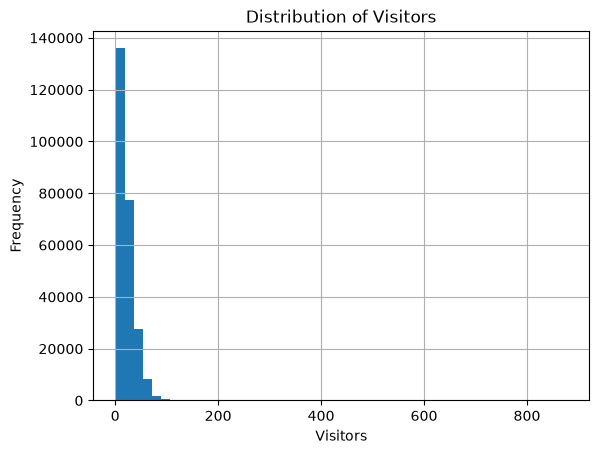

In [20]:
df['visitors'].hist(bins=50)
plt.title('Distribution of Visitors')
plt.xlabel('Visitors')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

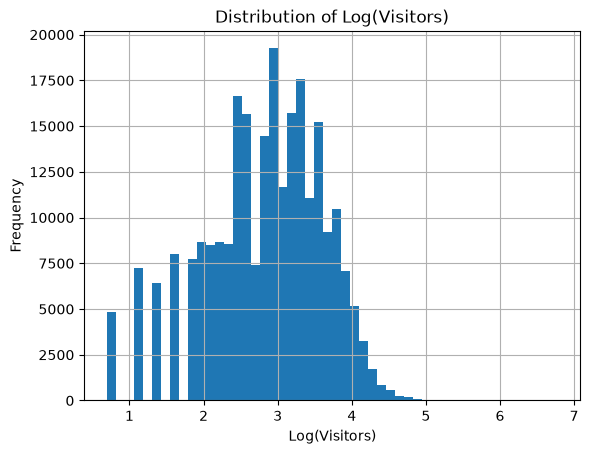

In [21]:
np.log1p(df['visitors']).hist(bins=50)
plt.title('Distribution of Log(Visitors)')
plt.xlabel('Log(Visitors)')
plt.ylabel('Frequency')

Text(0.5, 1.0, 'Boxplot of Visitors')

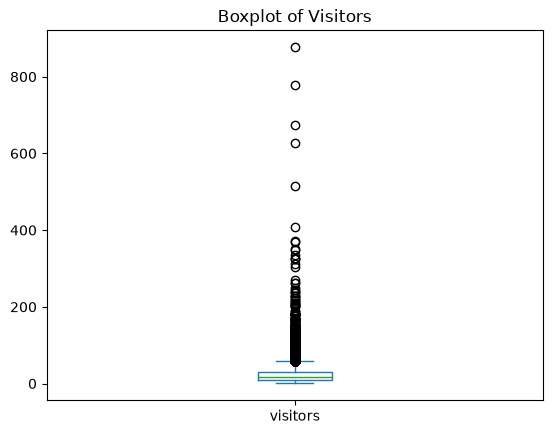

In [22]:
df['visitors'].plot(kind='box')
plt.title('Boxplot of Visitors')

Text(0.5, 1.0, 'Boxplot of log Visitors')

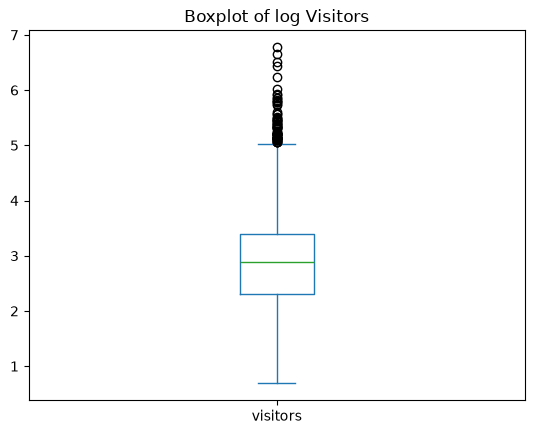

In [23]:
np.log1p(df['visitors']).plot(kind='box')
plt.title('Boxplot of log Visitors')

Text(0, 0.5, 'Total Visitors')

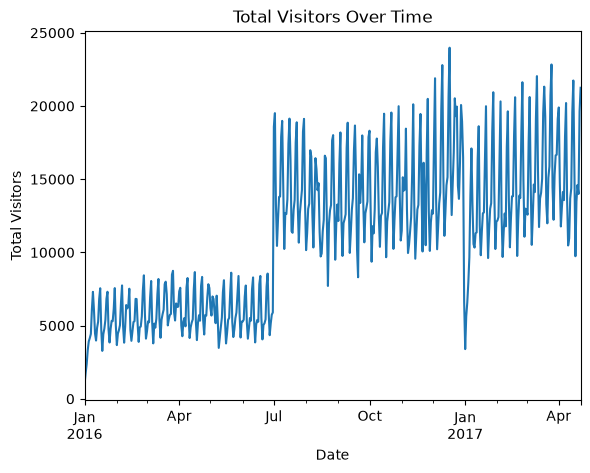

In [24]:
df.groupby('visit_date')['visitors'].sum().plot()
plt.title('Total Visitors Over Time')
plt.xlabel('Date')
plt.ylabel('Total Visitors')

Text(0, 0.5, 'Number of Unique Stores')

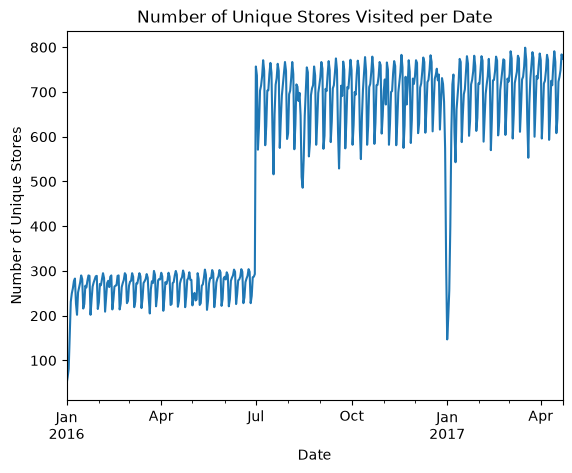

In [25]:
df.groupby('visit_date')['air_store_id'].nunique().plot()
plt.title('Number of Unique Stores Visited per Date')
plt.xlabel('Date')
plt.ylabel('Number of Unique Stores')

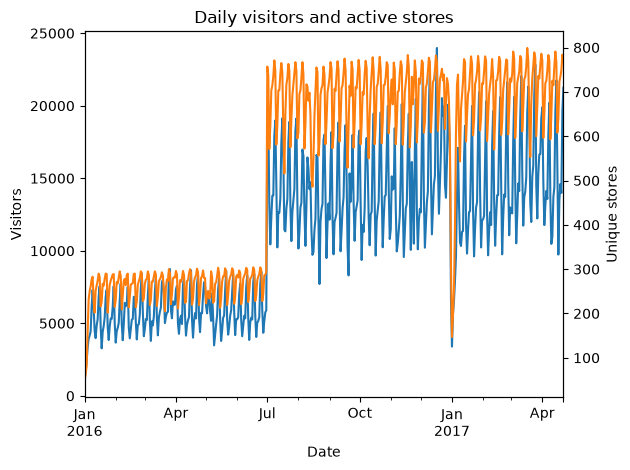

In [26]:
daily_visitors = df.groupby('visit_date')['visitors'].sum()
daily_stores = df.groupby('visit_date')['air_store_id'].nunique()

ax = daily_visitors.plot(label='Total visitors', color='tab:blue')
daily_stores.plot(ax=ax, secondary_y=True, label='Unique stores', color='tab:orange')

ax.set_title('Daily visitors and active stores')
ax.set_xlabel('Date')
ax.set_ylabel('Visitors')
ax.right_ax.set_ylabel('Unique stores')
plt.tight_layout()